# Анализ вендинговых автоматов Японии 🍜

-----------
**Цель исследования** — выявить наиболее прибыльные точки для установки вендинговых автоматов в Японии, учитывая культурную специфику рынка и уровень конкуренции в каждой локации.


**Бизнес-результат:** формирование рекомендаций по размещению автоматов в зонах с высоким пассажиропотоком и низкой плотностью конкурентов, что позволит максимизировать продажи и сократить риски неокупаемости.


**Что сделано:** собраны и систематизированы открытые данные о существующих точках размещения, плотности конкурентов и спросе в ключевых регионах Японии. 

**Источники:** OpenStreetMap (Overpass API), справочник цен операторов, e-Stat Japan

> <span style="color: #3e3225;">💡 **Япония** — один из самых насыщенных вендингом рынков мира: здесь работает **~5 млн автоматов**. При такой высокой конкуренции выбор локации становится **ключевым фактором успеха**.

## Описание данных

**`Датасет analysis_by_category`:**

  - `category_group` — группы категорий (Beverages, Food, Tobacco, Alcohol, Health & Hygiene, Electronics & Misc, Services,Other/Unknown)
  - `vending_category` — Подкатегория товаров
  - `count` — Количество подкатегорий
  - `avg_vending_price` — Средняя цена товара ¥
  - `avg_markup_pct` — Средняя наценка оператора %
  - `avg_monthly_profit` — Среднемесячная прибыль на автомат ¥
  - `avg_payback_months` — Средний срок окупаемости в месяцах


**`Датасет analysis_by_operator`:**
  - `operator_normalized` — Название оператора ('Unknown' — автомат без указанного оператора)
  - `machines_count` — Количество вендинговых аппаратов у оператора
  - `regions_count` — В скольких из 6 регионов представлен
  - `pct_24h` — Доля круглосуточных автоматов у оператора
  - `pct_ic_card` — Доля автоматов с приёмом IC-карты
  - `avg_markup_pct` — Средняя наценка оператора %
  - `avg_monthly_profit` — Среднемесячная прибыль ¥
  - `top_category` — Самая частая подкатегория товаров у оператора

**`Датасет analysis_by_region`:**
  - `region` — Регион Японии
  - `total_machines` — Общее число автоматов в регионе
  - `pct_24h`— Доля круглосуточных автоматов
  - `pct_beverages`  — Доля напитков
  - `pct_food`  — Доля еды
  - `pct_tobacco`  — Доля табака
  - `avg_markup_pct`  — Средняя наценка оператора %
  - `avg_monthly_revenue`  — Средняя выручка ¥
  - `avg_monthly_profit` — Среднемесячная прибыль 
  - `pct_profitable` — Доля прибыльных вендинговых аппаратов %

**`Датасет master_dataset`:**
 - `osm_id` — Уникальный идентификатор точки в OpenStreetMap (OSM)
 - `osm_type` — Тип OSM-объекта (у вендинговых автоматов всегда 'node')
 - `lat`,`lon` — Географические координаты автомата
 - `region` — Регион Японии
 - `vending_raw` — Исходное значение OSM-тега (public_transport_tickets,drinks, cigarettes и т.д.)
 - `vending_primary` — Основная категория, выделенная из `vending_raw`
 - `vending_category` — Подкатегория товара
 - `category_group` — Укрупнённая группа категорий
 - `operator` — Исходное название оператора из OSM (много пропусков)
 - `operator_normalized` — Название оператора
 - `opening_hours` — Исходный OSM-тег часов работы
 - `opening_hours_clean` — Обработанное значение часов работы
 - `is_24h` — Работает ли автомат круглосуточно (0/1)
 - `payment_cash/card/ic_card` — Принимает ли автомат наличные / карту / IC-карту (0/1)
 - `wheelchair, indoor, covered` — Вспомогательные OSM-теги доступности и расположения
 - `name, note` — Свободные текстовые OSM-теги
 - `avg_vending_price_jpy` — Средняя цена товара в этом автомате, ¥
 - `avg_retail_price_jpy` — Средняя розничная цена того же товара, ¥ 
 - `avg_markup_pct` — Наценка автомата к розничной цене, %
 - `daily_sales_est` — Оценка числа продаж в день
 - `monthly_revenue_jpy` — Оценочная выручка в месяц, ¥
 - `monthly_gross_profit_jpy` — Оценочная валовая прибыль в месяц, ¥
 - `monthly_net_profit_jpy` — Оценочная чистая прибыль в месяц, ¥
 - `payback_months` — Расчётный срок окупаемости, месяцев
 - `is_profitable` — Прибылен ли автомат (0/1: `monthly_net_profit_jpy` > 0)

## Оглавление


- [Загрузка данных и первичный осмотр](#Загрузка-данных-и-первичный-осмотр)
- [Очистка и валидация данных](#Очистка-и-валидация-данных)
- [Блок 2.1 — Анализ пропусков](#Блок-2.1—Анализ пропусков)
- [Разведочный анализ (EDA)](#Разведочный-анализ-(EDA))
- 

In [1]:
!pip install phik
!pip install missingno

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [2]:
# Импорт необходимых библиотек 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats
import plotly.express as px

In [3]:
# Выгрузка датасеитов
category = pd.read_csv('analysis_by_category.csv')
operator = pd.read_csv('analysis_by_operator.csv')
region = pd.read_csv('analysis_by_region.csv')
master_dataset = pd.read_csv('master_dataset.csv')

### Загрузка данных и первичный осмотр

In [4]:
# Создаем словарь и узнаем количество строк и столбцов в датафреймах
datasets = {
    'category':pd.read_csv('analysis_by_category.csv'),
    'operator':pd.read_csv('analysis_by_operator.csv'),
    'region' :pd.read_csv('analysis_by_region.csv'),
    'master_dataset':pd.read_csv('master_dataset.csv')
}

for name, df in datasets.items():
    print(f"Таблица '{name}': строк - {df.shape[0]}, столбцов - {df.shape[1]}")


Таблица 'category': строк - 121, столбцов - 7
Таблица 'operator': строк - 439, столбцов - 8
Таблица 'region': строк - 6, столбцов - 10
Таблица 'master_dataset': строк - 26807, столбцов - 31


In [5]:
# Выгрузка первых пяти строк
for df in datasets.values():
    display(df.head(5))

,category_group,vending_category,count,avg_vending_price,avg_markup_pct,avg_monthly_profit,avg_payback_months
0,Alcohol,Алкоголь (пиво),9,303.33,55.9,64525.33,4.82
1,Alcohol,Алкоголь (общее),4,303.33,55.9,46126.25,10.40
2,Alcohol,Алкоголь (саке),3,303.33,55.9,76852.00,4.27
3,Beverages,Напитки (общее),20660,166.35,56.5,35294.98,40898.62
4,Beverages,Кофе,186,166.35,56.5,37043.02,20980.00


,operator_normalized,machines_count,regions_count,pct_24h,pct_ic_card,avg_markup_pct,avg_monthly_profit,top_category
0,Unknown,19522,6,0.01,0.0,53.75,33704.44,Напитки (общее)
1,Coca-Cola,1688,6,0.02,0.0,56.49,33685.58,Напитки (общее)
2,Suntory,783,6,0.08,0.0,56.47,31601.18,Напитки (общее)
3,DyDo,600,6,0.03,0.0,56.50,34925.13,Напитки (общее)
4,Kirin Beverage,583,5,0.04,0.0,56.50,37974.05,Напитки (общее)


,region,total_machines,pct_24h,pct_beverages,pct_food,pct_tobacco,avg_markup_pct,avg_monthly_revenue,avg_monthly_profit,pct_profitable
0,kanto,17488,0.0,0.81,0.01,0.02,54.83,243429.22,46992.63,0.82
1,chubu,4676,0.1,0.78,0.02,0.04,53.64,158253.37,15662.36,0.80
2,chugoku,2724,0.0,0.66,0.02,0.03,53.80,100408.82,-1696.59,0.02
3,hokkaido,1064,0.0,0.77,0.02,0.03,53.95,100292.78,-1590.39,0.02
4,okinawa,538,0.0,0.78,0.03,0.03,54.32,119495.89,5591.72,0.81


,osm_id,osm_type,lat,lon,region,vending_raw,vending_primary,vending_category,category_group,operator,...,note,avg_vending_price_jpy,avg_retail_price_jpy,avg_markup_pct,daily_sales_est,monthly_revenue_jpy,monthly_gross_profit_jpy,monthly_net_profit_jpy,payback_months,is_profitable
0,1555169728,node,43.763039,142.357919,hokkaido,public_transport_tickets,public_transport_tickets,Прочее (public_transport_tickets),Other / Unknown,北海道旅客鉄道,...,NaN,NaN,NaN,NaN,18,NaN,NaN,NaN,NaN,0
1,1555752459,node,43.762670,142.359134,hokkaido,public_transport_tickets,public_transport_tickets,Прочее (public_transport_tickets),Other / Unknown,北海道旅客鉄道,...,NaN,NaN,NaN,NaN,18,NaN,NaN,NaN,NaN,0
2,1775913293,node,43.730989,142.365826,hokkaido,public_transport_tickets,public_transport_tickets,Прочее (public_transport_tickets),Other / Unknown,北海道旅客鉄道,...,NaN,NaN,NaN,NaN,18,NaN,NaN,NaN,NaN,0
3,2144929234,node,43.744976,142.358386,hokkaido,public_transport_tickets,public_transport_tickets,Прочее (public_transport_tickets),Other / Unknown,JR北海道,...,NaN,NaN,NaN,NaN,18,NaN,NaN,NaN,NaN,0
4,2152896706,node,43.765918,142.359128,hokkaido,public_transport_tickets,public_transport_tickets,Прочее (public_transport_tickets),Other / Unknown,旭川電気軌道,...,旭川空港線乗車券用 (Ticket of Asahikawa Airport Line),NaN,NaN,NaN,18,NaN,NaN,NaN,NaN,0


In [6]:
# Просмотр общей информации о данных
for df in datasets.values():
    display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   category_group      121 non-null    object 
 1   vending_category    121 non-null    object 
 2   count               121 non-null    int64  
 3   avg_vending_price   22 non-null     float64
 4   avg_markup_pct      22 non-null     float64
 5   avg_monthly_profit  22 non-null     float64
 6   avg_payback_months  22 non-null     float64
dtypes: float64(4), int64(1), object(2)
memory usage: 6.7+ KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439 entries, 0 to 438
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   operator_normalized  439 non-null    object 
 1   machines_count       439 non-null    int64  
 2   regions_count        439 non-null    int64  
 3   pct_24h              439 non-null    float64
 4   pct_ic_card          439 non-null    float64
 5   avg_markup_pct       332 non-null    float64
 6   avg_monthly_profit   332 non-null    float64
 7   top_category         439 non-null    object 
dtypes: float64(4), int64(2), object(2)
memory usage: 27.6+ KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   region               6 non-null      object 
 1   total_machines       6 non-null      int64  
 2   pct_24h              6 non-null      float64
 3   pct_beverages        6 non-null      float64
 4   pct_food             6 non-null      float64
 5   pct_tobacco          6 non-null      float64
 6   avg_markup_pct       6 non-null      float64
 7   avg_monthly_revenue  6 non-null      float64
 8   avg_monthly_profit   6 non-null      float64
 9   pct_profitable       6 non-null      float64
dtypes: float64(8), int64(1), object(1)
memory usage: 612.0+ bytes


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26807 entries, 0 to 26806
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   osm_id                    26807 non-null  int64  
 1   osm_type                  26807 non-null  object 
 2   lat                       26807 non-null  float64
 3   lon                       26807 non-null  float64
 4   region                    26807 non-null  object 
 5   vending_raw               24023 non-null  object 
 6   vending_primary           26807 non-null  object 
 7   vending_category          26807 non-null  object 
 8   category_group            26807 non-null  object 
 9   operator                  7285 non-null   object 
 10  operator_normalized       26807 non-null  object 
 11  opening_hours             532 non-null    object 
 12  opening_hours_clean       26807 non-null  object 
 13  is_24h                    26807 non-null  int64  
 14  paymen

None

In [7]:
# Количество уникальных значений в столбцах
for name, df in datasets.items():
    print(f"Таблица '{name}':")
    for column_name, unique_count in df.nunique().items():
        print(f"  Столбец '{column_name}': {unique_count}")
    print("-" * 20)

Таблица 'category':
  Столбец 'category_group': 8
  Столбец 'vending_category': 121
  Столбец 'count': 28
  Столбец 'avg_vending_price': 6
  Столбец 'avg_markup_pct': 6
  Столбец 'avg_monthly_profit': 18
  Столбец 'avg_payback_months': 18
--------------------
Таблица 'operator':
  Столбец 'operator_normalized': 439
  Столбец 'machines_count': 43
  Столбец 'regions_count': 6
  Столбец 'pct_24h': 19
  Столбец 'pct_ic_card': 6
  Столбец 'avg_markup_pct': 20
  Столбец 'avg_monthly_profit': 60
  Столбец 'top_category': 35
--------------------
Таблица 'region':
  Столбец 'region': 6
  Столбец 'total_machines': 6
  Столбец 'pct_24h': 2
  Столбец 'pct_beverages': 5
  Столбец 'pct_food': 3
  Столбец 'pct_tobacco': 4
  Столбец 'avg_markup_pct': 6
  Столбец 'avg_monthly_revenue': 6
  Столбец 'avg_monthly_profit': 6
  Столбец 'pct_profitable': 5
--------------------
Таблица 'master_dataset':
  Столбец 'osm_id': 26807
  Столбец 'osm_type': 1
  Столбец 'lat': 26655
  Столбец 'lon': 26670
  Столбец '

In [8]:
# Общая статистика данных
for name, df in datasets.items():
    print(f"Таблица '{name}':")
    display(df.describe())

Таблица 'category':


,count,avg_vending_price,avg_markup_pct,avg_monthly_profit,avg_payback_months
count,121.000000,22.000000,22.000000,22.000000,22.000000
mean,221.545455,475.090909,62.248182,178288.270909,35369.127273
std,1893.762472,348.405410,30.950520,238348.551264,87626.036699
min,1.000000,166.350000,0.000000,-33000.000000,0.500000
25%,1.000000,216.660000,45.160000,37030.540000,1.322500
50%,1.000000,303.330000,56.200000,52060.625000,7.800000
75%,4.000000,895.000000,100.000000,235632.552500,17162.492500
max,20660.000000,1000.000000,104.800000,642000.000000,300000.000000


Таблица 'operator':


,machines_count,regions_count,pct_24h,pct_ic_card,avg_markup_pct,avg_monthly_profit
count,439.000000,439.000000,439.000000,439.000000,332.000000,332.000000
mean,61.063781,1.246014,0.027449,0.007631,53.926747,35060.348524
std,936.716365,0.845928,0.140011,0.083120,9.906061,45129.999836
min,1.000000,1.000000,0.000000,0.000000,0.000000,-33000.000000
25%,1.000000,1.000000,0.000000,0.000000,56.500000,17447.000000
50%,1.000000,1.000000,0.000000,0.000000,56.500000,48076.000000
75%,3.000000,1.000000,0.000000,0.000000,56.500000,48076.000000
max,19522.000000,6.000000,1.000000,1.000000,104.800000,642000.000000


Таблица 'region':


,total_machines,pct_24h,pct_beverages,pct_food,pct_tobacco,avg_markup_pct,avg_monthly_revenue,avg_monthly_profit,pct_profitable
count,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000
mean,4467.833333,0.016667,0.748333,0.020000,0.033333,53.840000,135944.720000,9845.326667,0.411667
std,6585.865423,0.040825,0.059133,0.006325,0.010328,0.782279,57675.276218,19714.842014,0.436459
min,317.000000,0.000000,0.660000,0.010000,0.020000,52.500000,93788.240000,-5887.770000,0.000000
25%,669.500000,0.000000,0.710000,0.020000,0.030000,53.680000,100321.790000,-1670.040000,0.020000
50%,1894.000000,0.000000,0.775000,0.020000,0.030000,53.875000,109952.355000,2000.665000,0.410000
75%,4188.000000,0.000000,0.780000,0.020000,0.037500,54.227500,148564.000000,13144.700000,0.807500
max,17488.000000,0.100000,0.810000,0.030000,0.050000,54.830000,243429.220000,46992.630000,0.820000


Таблица 'master_dataset':


,osm_id,lat,lon,is_24h,payment_cash,payment_card,payment_ic_card,avg_vending_price_jpy,avg_retail_price_jpy,avg_markup_pct,daily_sales_est,monthly_revenue_jpy,monthly_gross_profit_jpy,monthly_net_profit_jpy,payback_months,is_profitable
count,2.680700e+04,26807.000000,26807.000000,26807.000000,26807.000000,26807.000000,26807.000000,22261.000000,22261.000000,22261.000000,26807.000000,2.226100e+04,22261.000000,22261.000000,22261.000000,26807.000000
mean,8.655407e+09,35.577308,138.317893,0.019323,0.103480,0.003357,0.001716,182.629925,127.087645,54.461925,37.414854,2.060918e+05,66869.939536,33869.939536,48671.588702,0.695714
std,3.786783e+09,2.111608,2.669265,0.137661,0.304591,0.057846,0.041389,79.887831,86.232715,10.569107,10.791426,1.060283e+05,29490.547678,29490.547678,110592.498065,0.460113
min,5.712664e+07,24.259380,123.777503,0.000000,0.000000,0.000000,0.000000,166.350000,109.600000,0.000000,16.000000,7.984800e+04,0.000000,-33000.000000,0.500000,0.000000
25%,5.484422e+09,35.196682,137.410533,0.000000,0.000000,0.000000,0.000000,166.350000,109.600000,56.500000,28.000000,1.397340e+05,50447.000000,17447.000000,6.200000,0.000000
50%,9.449065e+09,35.654734,139.544305,0.000000,0.000000,0.000000,0.000000,166.350000,109.600000,56.500000,45.000000,2.245720e+05,81076.000000,48076.000000,6.200000,1.000000
75%,1.209081e+10,35.758241,139.746706,0.000000,0.000000,0.000000,0.000000,166.350000,109.600000,56.500000,45.000000,2.245720e+05,81076.000000,48076.000000,17.200000,1.000000
max,1.400648e+10,45.517434,144.794461,1.000000,1.000000,1.000000,1.000000,1000.000000,580.000000,104.800000,45.000000,1.350000e+06,675000.000000,642000.000000,300000.000000,1.000000


In [9]:
# Проверяем на дубликаты, в случая наличия дубликаты будут удалены
for name, df in datasets.items():
    duplicate_count = df.duplicated().sum()
    if duplicate_count > 0:
        print(f"В таблице '{name}' найдено {duplicate_count} дубликатов. Удаляем...")
    else:
        print(f"Таблица '{name}': Дубликатов не найдено.")

Таблица 'category': Дубликатов не найдено.
Таблица 'operator': Дубликатов не найдено.
Таблица 'region': Дубликатов не найдено.
Таблица 'master_dataset': Дубликатов не найдено.


In [10]:
# Проверяем количество пропусков
found_issues = False
for name, df in datasets.items():
    missing_counts = df.isna().sum()
    only_missing = missing_counts[missing_counts > 0]
    if not only_missing.empty:
        found_issues = True
        print(f"\nОбнаружены пропуски в таблице '{name}':")
        print(only_missing)
        print("-" * 30)
if not found_issues:
    print("Во всех таблицах данных пропусков не найдено.")


Обнаружены пропуски в таблице 'category':
avg_vending_price     99
avg_markup_pct        99
avg_monthly_profit    99
avg_payback_months    99
dtype: int64
------------------------------

Обнаружены пропуски в таблице 'operator':
avg_markup_pct        107
avg_monthly_profit    107
dtype: int64
------------------------------

Обнаружены пропуски в таблице 'master_dataset':
vending_raw                  2784
operator                    19522
opening_hours               26275
wheelchair                  26435
indoor                      26262
covered                     26572
name                        21697
note                        26672
avg_vending_price_jpy        4546
avg_retail_price_jpy         4546
avg_markup_pct               4546
monthly_revenue_jpy          4546
monthly_gross_profit_jpy     4546
monthly_net_profit_jpy       4546
payback_months               4546
dtype: int64
------------------------------


Для анализа загружены четыре таблицы: три справочника (category — 121 строка, operator — 439, region — 6) и основной массив данных master_dataset — 26 807 записей, по одной на каждый автомат. Дубликаты отсутствуют во всех таблицах. Связи между таблицами корректны: число уникальных категорий, операторов и регионов в master_dataset полностью совпадает с числом строк в соответствующих справочниках.

Итоги:

- Некорректное значение срока окупаемости. Как в category, так и в master_dataset максимальное значение payback_months составляет ровно 300 000 месяцев. Это не фактический показатель, а техническая заглушка, используемая для убыточных автоматов.
- Ограниченная вариативность финансовых показателей. Среди 22 261 автомата с известной прибылью встречается всего 6 уникальных значений цены, 6 значений наценки и 5 значений оценки дневных продаж.
- Групповые пропуски в финансовых данных. У 99 из 121 подкатегории товаров одновременно отсутствуют данные о цене, наценке, прибыли и сроке окупаемости — пропуски идут не по отдельным колонкам, а блоком.


### 1. Очистка и валидация данных

#### Блок 1.1 — Анализ пропусков `master_dataset`

In [11]:
# Считаем долю пропусков по каждой колонке в процентах
missing_pct = (master_dataset.isna().sum() / len(master_dataset) * 100).round(2)

# Оставляем только колонки, где пропуски вообще есть, и сортируем по убыванию
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

print("Доля пропусков по колонкам (%):")
display(missing_pct)


Доля пропусков по колонкам (%):


note                        99.50
covered                     99.12
wheelchair                  98.61
opening_hours               98.02
indoor                      97.97
name                        80.94
operator                    72.82
avg_vending_price_jpy       16.96
avg_retail_price_jpy        16.96
avg_markup_pct              16.96
monthly_revenue_jpy         16.96
monthly_gross_profit_jpy    16.96
monthly_net_profit_jpy      16.96
payback_months              16.96
vending_raw                 10.39
dtype: float64

**Итого количество колонок с пропусками: 15**

В master_dataset пропуски в основном в OSM-значениях: они встречаются в 15 колонках, например: `note` (99,5%), `covered` (99,12%), `wheelchair` (98,61%), `opening_hours` (98,02%), `indoor` (97,97%), `name` (80,94%), `operator` (72,82%).

Другую категорию пропусков можно отнести к финансовым показателям со значением 16,96% от общего числа данных (`avg_vending_price_jpy`, `avg_retail_price_jpy`, `avg_markup_pct`, `monthly_revenue_jpy`, `monthly_gross_profit_jpy`, `monthly_net_profit_jpy`, `payback_months`).

7 колонок имеют больше 50% пропусков: `operator` (72.82%), `name` (80.94%), `indoor` (97.97%), `opening_hours` (98.02%), `wheelchair` (98.61%), `covered` (99.12%), `note` (99.50%). При таком количестве пропусков любая статистика по колонке ненадёжна и может ввести в заблуждение. Данные колонки удаляем.

❗**Наличие одинакового процента пропусков не является случайностью. Необходимо дальнейшее исследование.**

In [12]:
# Сравнения значения 'Unknown' и пропусков в operator_normalized
unknown_count = (master_dataset['operator_normalized'] == 'Unknown').sum()
missing_operator_count = master_dataset['operator'].isna().sum()

print(f"Значений Unknown в operator_normalized: {unknown_count}")
print(f"Пропусков в исходной колонке operator:    {missing_operator_count}")


Значений Unknown в operator_normalized: 19522
Пропусков в исходной колонке operator:    19522


По результатам сравнения значение `Unknown` является заглушкой для пропущенных данных. Колонку оставляем без изменений, значения `Unknown` не заменяем и строки с ними не удаляем.

In [13]:
# Смотрим, к каким category_group относятся автоматы без данных о прибыли
missing_profit = master_dataset[master_dataset['monthly_net_profit_jpy'].isna()]

print(f"Автоматов без финансовых данных: {len(missing_profit)}")
print("\nРаспределение по category_group:")
display(missing_profit['category_group'].value_counts())


Автоматов без финансовых данных: 4546

Распределение по category_group:


category_group
Other / Unknown    3546
Services           1000
Name: count, dtype: int64

Финансовые показатели рассчитаны только для массовых категорий товаров. Для остальных редких видов данных нет  — это ожидаемый пробел, а не ошибка. Строки удалять не нужно, но при подсчёте финансовых метрик их следует фильтровать по пустым значениям.


**Вывод по Блоку 1.1:**

- Удаление: 7 колонок с критическим уровнем пропусков (>50%: от operator — 72,82% до note — 99,5%) удаляются из датасета.
- Финансовые метрики: Пропуски в финансовых показателях (16,96%) являются ожидаемыми для редких категорий товаров. Строки сохраняются, но при агрегации данных их необходимо фильтровать по пустым значениям.
- Маркер Unknown: Значения 'Unknown' признаны валидными заглушками вместо пропущенных данных. Колонка сохраняется без изменений, замена или удаление строк не требуются.
- Аномалия: Одинаковый процент пропусков в OSM-колонках выглядит системным и требует дальнейшего исследования причин синхронизированного отсутствия данных.


#### Блок 1.2 — Проверка диапазонов и выбросов

In [14]:
# Считаем окупаемость автоматов по истечению 10 лет 
long_payback = master_dataset[master_dataset['payback_months'] > 120]

share = len(long_payback) / master_dataset['payback_months'].notna().sum() * 100
print(f"Автоматов со сроком окупаемости больше 120 месяцев: {len(long_payback)}")
print(f"Это {share:.1f}% от всех, где payback_months известен")

Автоматов со сроком окупаемости больше 120 месяцев: 3611
Это 16.2% от всех, где payback_months известен


In [15]:
# Наиболее большие показатели окупаемости 
display(
    long_payback[['vending_category', 'region', 'monthly_net_profit_jpy', 'payback_months']]
    .sort_values('payback_months', ascending=False)
    .head(10)
)

,vending_category,region,monthly_net_profit_jpy,payback_months
6,Напитки (общее),hokkaido,-570.0,300000.0
24509,Напитки (общее),chugoku,-570.0,300000.0
24562,Напитки (общее),chugoku,-570.0,300000.0
24564,Напитки (общее),chugoku,-570.0,300000.0
24565,Напитки (общее),chugoku,-570.0,300000.0
24566,Напитки (общее),chugoku,-570.0,300000.0
24570,Напитки (общее),chugoku,-570.0,300000.0
24571,Напитки (общее),chugoku,-570.0,300000.0
24572,Напитки (общее),chugoku,-570.0,300000.0
24579,Сигареты,chugoku,-33000.0,300000.0


`payback_months` (окупаемость) имеет аномальное значение 300 000 месяцев (25 000 лет). У этих строк выручка меньше расходов (аренда точки, электричество, пополнение товара и т. п.) — то есть автомат в этих условиях (категория + регион + объём продаж) убыточен по модели. Из-за этого возникает аномальное значение. У всех 3611 автоматов с отрицательной прибылью `payback_months` равен ровно 300 000. Это означает: 300 000 — не реальный расчёт, а искусственная заглушка, необходимая для расчёта при отрицательном балансе. Вместо удаления помечаем такие строки отдельным флагом (`payback_months_outlier`) и при расчёте среднего/медианы по `payback_months` в дальнейшем анализе исключаем их через фильтр, а не удаляем из датафрейма.

In [16]:
# Считаем автоматы с отрицательной прибылью
negative_profit = master_dataset[master_dataset['monthly_net_profit_jpy'] < 0]

print(f"Автоматов с отрицательной monthly_net_profit_jpy: {len(negative_profit)}")

print("\nПо регионам:")
display(negative_profit['region'].value_counts())

print("\nПо категориям (category_group):")
display(negative_profit['category_group'].value_counts())


Автоматов с отрицательной monthly_net_profit_jpy: 3611

По регионам:


region
chugoku     1889
hokkaido     859
kanto        419
shikoku      242
chubu        188
okinawa       14
Name: count, dtype: int64


По категориям (category_group):


category_group
Beverages    2848
Tobacco       757
Food            6
Name: count, dtype: int64

В данных есть автоматы с отрицательной `monthly_net_profit_jpy` (по `.describe()` минимум -33 000 ¥/мес.). По агрегированной таблице `region` (раздел "Описание данных") уже видно, что в `chugoku` и `hokkaido` средняя прибыль отрицательна (-1696.59 ¥ и -1590.39 ¥ соответственно).Разбивка выше по `region` и `category_group` показывает точную картину на уровне отдельных автоматов.

Отрицательные значения не удаляем и не заменяем — строки оставляем в `df_clean`. Для вопроса "прибылен ли автомат" опираемся на готовый флаг `is_profitable`, а не пытаемся "чинить" саму сумму прибыли. удаление убыточных автоматов исказило бы результат исследования — как раз цель работы понять, где и почему автоматы не окупаются, чтобы не повторять эти ошибки при выборе новых локаций.

In [17]:
# Проверяем наценку на аномальные значения
bad_markup = master_dataset[(master_dataset['avg_markup_pct'] < 0) | (master_dataset['avg_markup_pct'] > 500)]

print(f"Строк с avg_markup_pct < 0 или > 500%: {len(bad_markup)}")
display(bad_markup[['vending_category', 'avg_markup_pct']].head(10))

Строк с avg_markup_pct < 0 или > 500%: 0


,vending_category,avg_markup_pct


**Вывод по Блоку 1.2:**

- Убыточность: в данных есть автоматы с отрицательной чистой прибылью (минимум -33 000 ¥/мес.).
- Строки с убытками сохраняются в датафрейме (df_clean), аномальная наценка на товары отсутствует. Для определения статуса используется готовый флаг is_profitable.
- Удаление или замена этих значений исказит аналитику. Главная задача работы — выявить локации и условия, где автоматы генерируют убытки, чтобы избежать подобных ошибок при масштабировании сети.

#### Блок 1.3 — Проверка категориальных переменных

In [18]:
# Считаем количество автоматов на каждую подкатегорию товаров
category_counts = master_dataset['vending_category'].value_counts()

rare_categories = category_counts[category_counts < 10]

print(f"Всего уникальных категорий: {category_counts.shape[0]}")
print(f"Из них редких (меньше 10 автоматов): {rare_categories.shape[0]}")
print(f"Суммарно автоматов в редких категориях: {rare_categories.sum()} из {len(master_dataset)}")

display(rare_categories)


Всего уникальных категорий: 121
Из них редких (меньше 10 автоматов): 96
Суммарно автоматов в редких категориях: 151 из 26807


vending_category
Алкоголь (пиво)              9
Прочее (animal_feed)         6
Прочее (storage)             5
Прочее (lockers)             5
Прочее (vegetables)          5
                            ..
Прочее (pokemon plushies)    1
Прочее (exchange)            1
Прочее (mobile battery)      1
Прочее (photograph)          1
Прочее (beverage)            1
Name: count, Length: 96, dtype: int64

Поскольку заметная часть из 121 подкатегории `vending_category` встречается крайне редко, для очистки визуализаций и группировок создаём вспомогательную колонку `vending_category_grouped`, объединяя все категории с числом автоматов менее 10 в группу `«Прочее»`, при этом сохраняя исходный столбец vending_category неизменным в `df_clean`. Такое решение продиктовано тем, что по категориям с выборкой от 1 до 9 автоматов невозможно надёжно оценить среднюю прибыль или окупаемость, а на графиках они создают длинный статистический шум; выбрасывать эти автоматы нельзя, так как суммарно они составляют ощутимую долю наблюдений. Новая группировка дополняет уже существующую более крупную категорию `category_group` и применяется только там, где важен анализ на уровне подкатегорий, но мешают её редкие значения.

In [19]:
# Проверяем регионы на опечатки и разный регистр
print("Уникальные значения region:")
print(master_dataset['region'].unique())
print(f"\nКоличество уникальных регионов: {master_dataset['region'].nunique()}")


Уникальные значения region:
['hokkaido' 'kanto' 'chubu' 'chugoku' 'shikoku' 'okinawa']

Количество уникальных регионов: 6


#### Блок 1.3 — Итог главы

Собираем итоги всех проверок в один датафрейм `df_clean`:
- убираем описательные колонки с пропусками выше 50%, которые не нужны для дальнейшего анализа (см. Блок 2.1);
- добавляем `vending_category_grouped` — редкие подкатегории (< 10 автоматов) объединены в `'Прочее'` (см. Блок 2.3);
- добавляем `payback_months_outlier` — флаг для срока окупаемости больше 120 месяцев, чтобы такие строки можно было легко исключить из расчёта средних/медиан, не удаляя сами автоматы (см. Блок 2.2).

Строки при этом **не удаляем** — ни один из найденных пропусков или выбросов не оказался ошибкой сбора данных, которая требовала бы физического удаления записей.

In [20]:
# Копируем исходный датафрейм
df_clean = master_dataset.copy()

# Убираем описательные колонки с пропусками выше 50% они не нужны для дальнейшего исследования 
columns_to_drop = ['operator', 'opening_hours', 'wheelchair', 'indoor', 'covered', 'name', 'note']
df_clean = df_clean.drop(columns=columns_to_drop)

# Добавляем укрупнённую категорию: редкие подкатегории (< 10 автоматов) объединяем в 'Прочее'
df_clean['vending_category_grouped'] = df_clean['vending_category'].apply(
    lambda x: 'Прочее' if x in rare_categories.index else x
)

# Помечаем аномально долгий срок окупаемости флагом, но не удаляем сами строки
df_clean['payback_months_outlier'] = df_clean['payback_months'] > 120

print(f"Размер df_clean: {df_clean.shape[0]} строк, {df_clean.shape[1]} столбцов")
display(df_clean.head())


Размер df_clean: 26807 строк, 26 столбцов


,osm_id,osm_type,lat,lon,region,vending_raw,vending_primary,vending_category,category_group,operator_normalized,...,avg_retail_price_jpy,avg_markup_pct,daily_sales_est,monthly_revenue_jpy,monthly_gross_profit_jpy,monthly_net_profit_jpy,payback_months,is_profitable,vending_category_grouped,payback_months_outlier
0,1555169728,node,43.763039,142.357919,hokkaido,public_transport_tickets,public_transport_tickets,Прочее (public_transport_tickets),Other / Unknown,北海道旅客鉄道,...,NaN,NaN,18,NaN,NaN,NaN,NaN,0,Прочее (public_transport_tickets),False
1,1555752459,node,43.762670,142.359134,hokkaido,public_transport_tickets,public_transport_tickets,Прочее (public_transport_tickets),Other / Unknown,北海道旅客鉄道,...,NaN,NaN,18,NaN,NaN,NaN,NaN,0,Прочее (public_transport_tickets),False
2,1775913293,node,43.730989,142.365826,hokkaido,public_transport_tickets,public_transport_tickets,Прочее (public_transport_tickets),Other / Unknown,北海道旅客鉄道,...,NaN,NaN,18,NaN,NaN,NaN,NaN,0,Прочее (public_transport_tickets),False
3,2144929234,node,43.744976,142.358386,hokkaido,public_transport_tickets,public_transport_tickets,Прочее (public_transport_tickets),Other / Unknown,JR北海道,...,NaN,NaN,18,NaN,NaN,NaN,NaN,0,Прочее (public_transport_tickets),False
4,2152896706,node,43.765918,142.359128,hokkaido,public_transport_tickets,public_transport_tickets,Прочее (public_transport_tickets),Other / Unknown,旭川電気軌道,...,NaN,NaN,18,NaN,NaN,NaN,NaN,0,Прочее (public_transport_tickets),False


### 2. Разведочный анализ (EDA)

Работаем с `df_clean`

#### Блок 2.1 — Распределение по категориям

In [21]:
# Создаем цветовую гамму
category_groups_unique = sorted(df_clean['category_group'].dropna().unique())

base_colors = {
    'Beverages': '#2E86AB',   # синий - напитки
    'Food': '#5B8C5A',        # зелёный - еда
    'Tobacco': '#8B7355',     # коричневый - табак
    'Alcohol': '#6B4C7A',     # фиолетовый - алкоголь
}
gray_shades = ['#9B9B9B', '#B0B0B0', '#7F7F7F', '#A5A5A5', '#8C8C8C']

category_colors = {}
gray_i = 0
for cg in category_groups_unique:
    if cg in base_colors:
        category_colors[cg] = base_colors[cg]
    else:
        category_colors[cg] = gray_shades[gray_i % len(gray_shades)]
        gray_i += 1

print("Палитра по category_group:")
for cg, color in category_colors.items():
    print(f"  {cg}: {color}")


Палитра по category_group:
  Alcohol: #6B4C7A
  Beverages: #2E86AB
  Electronics & Misc: #9B9B9B
  Food: #5B8C5A
  Health & Hygiene: #B0B0B0
  Other / Unknown: #7F7F7F
  Services: #A5A5A5
  Tobacco: #8B7355


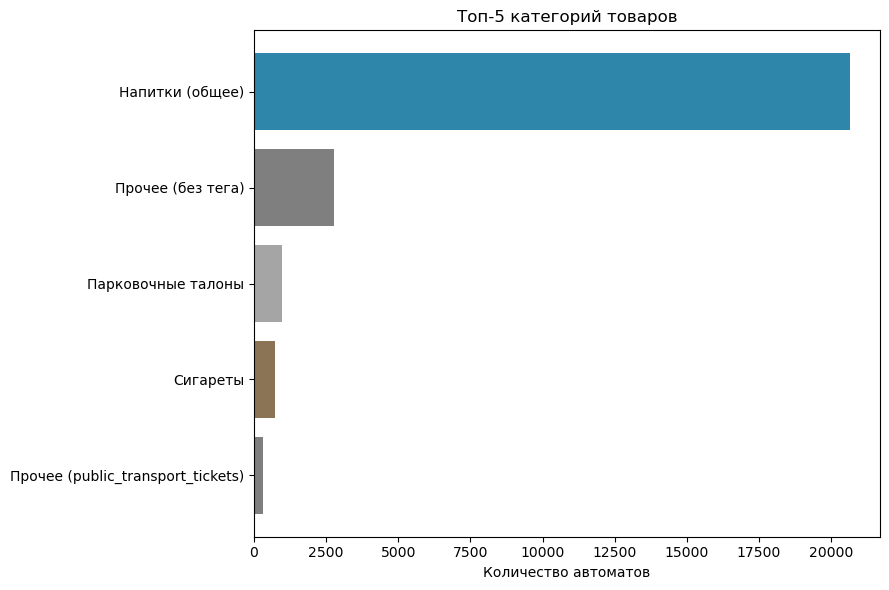

In [22]:
# Топ-5 подкатегорий товаров по количеству автоматов
top15 = df_clean['vending_category'].value_counts().head(5).sort_values()

top15_groups = (
    df_clean.drop_duplicates('vending_category')
    .set_index('vending_category')
    .loc[top15.index, 'category_group']
)
bar_colors = [category_colors[g] for g in top15_groups]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top15.index.astype(str), top15.values, color=bar_colors)
ax.set_xlabel('Количество автоматов')
ax.set_title('Топ-5 категорий товаров')
plt.tight_layout()
plt.show()


Основная масса вендинговых автоматов приходится на категорию напитков — её объём многократно превышает показатели остальных категорий. Это указывает на то, что рынок вендинга в первую очередь ориентирован на товары регулярного и быстрого потребления. При этом значительная доля категории «прочее» может говорить о широком спектре специализированных автоматов. Парковочные и транспортные автоматы занимают небольшую долю, поскольку относятся скорее к инфраструктурному, чем к классическому торговому вендингу.

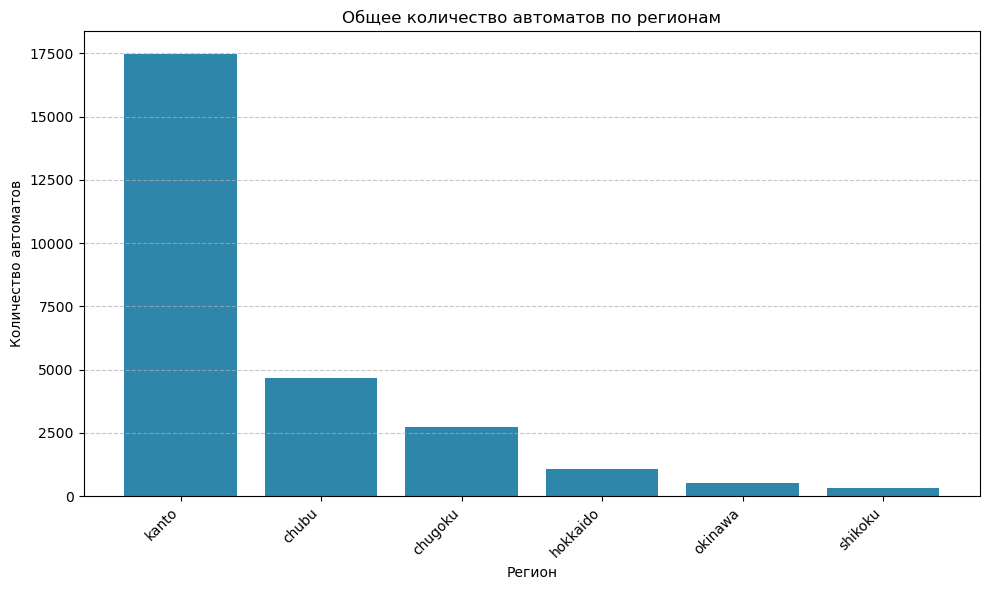

In [23]:
# Строим столбчатый график с количеством вендинговых автоматов, в разрезе регионов Японии
region_totals = df_clean['region'].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(region_totals.index, region_totals.values, color='#2E86AB')
plt.xlabel('Регион')
plt.ylabel('Количество автоматов')
plt.title('Общее количество автоматов по регионам')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

По мере удаления от крупнейшего экономического центра количество автоматов заметно сокращается, что показывает зависимость вендингового рынка от плотности населения и уровня городской активности.

#### Блок 2.2 — Часы работы и способы оплаты

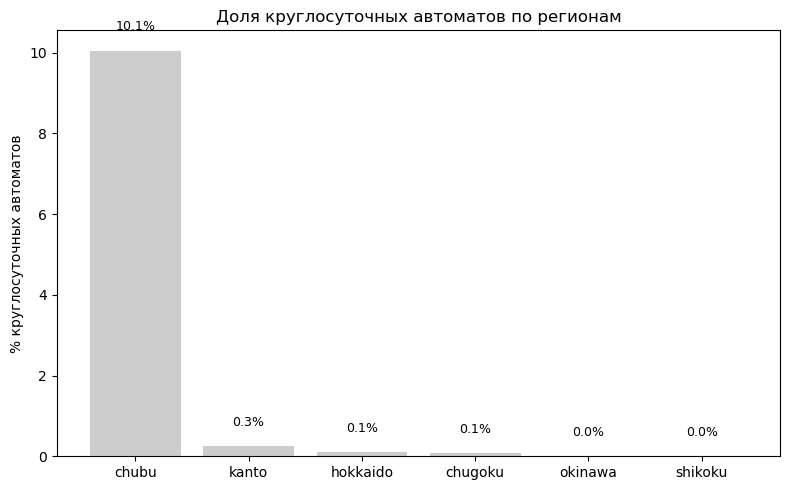

In [24]:
# Доля круглосуточных автоматов (is_24h) по регионам
share_24h_by_region = (df_clean.groupby('region')['is_24h'].mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(share_24h_by_region.index, share_24h_by_region.values, color='#cccccc')
ax.set_ylabel('% круглосуточных автоматов')
ax.set_title('Доля круглосуточных автоматов по регионам')
for i, value in enumerate(share_24h_by_region.values):
    ax.text(i, value + 0.5, f'{value:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()


Круглосуточный режим — редкость почти везде: 5 из 6 регионов практически не используют его (0.0–0.3%). Единственное исключение — Chubu (10.1%), где его доля значительно выше остальных.

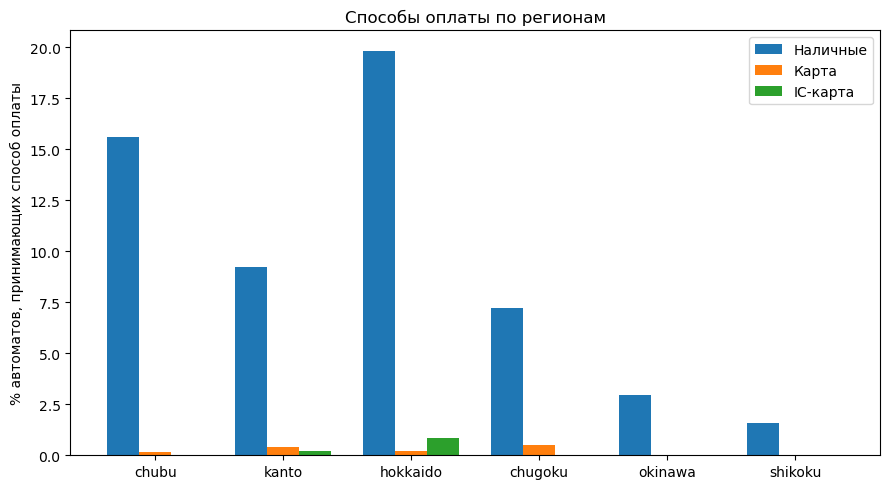

In [25]:
# Доля автоматов, принимающих каждый способ оплаты, по регионам
payment_by_region = df_clean.groupby('region')[['payment_cash', 'payment_card', 'payment_ic_card']].mean() * 100
payment_by_region = payment_by_region.reindex(share_24h_by_region.index)

x = np.arange(len(payment_by_region))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width, payment_by_region['payment_cash'], width, label='Наличные')
ax.bar(x, payment_by_region['payment_card'], width, label='Карта')
ax.bar(x + width, payment_by_region['payment_ic_card'], width, label='IC-карта')

ax.set_xticks(x)
ax.set_xticklabels(payment_by_region.index)
ax.set_ylabel('% автоматов, принимающих способ оплаты')
ax.set_title('Способы оплаты по регионам')
ax.legend()
plt.tight_layout()
plt.show()


График показывает, что наличные остаются основным способом оплаты во всех регионах Японии: их принимают примерно 2–20% автоматов в зависимости от региона, тогда как банковские карты распространены значительно слабее.

При этом заметна региональная специфика безналичной оплаты. В hokkaido и kanto относительно заметна доля автоматов, принимающих IC-карты, тогда как в okinawa и shikoku их практически нет. Это может отражать различия в развитии транспортной и платежной инфраструктуры и особенности локального спроса.

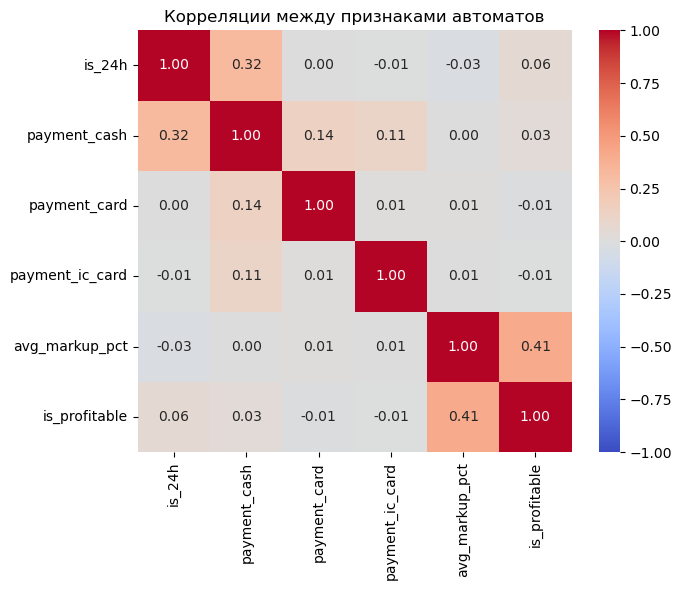

In [26]:
# Матрица корреляций между ключевыми числовыми/бинарными признаками
corr_columns = ['is_24h', 'payment_cash', 'payment_card', 'payment_ic_card', 'avg_markup_pct', 'is_profitable']
corr_matrix = df_clean[corr_columns].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Корреляции между признаками автоматов')
plt.tight_layout()
plt.show()


Наценка — один из ключевых управляемых факторов прибыльности автомата: чем выше наценка, тем выше вероятность того, что автомат будет приносить прибыль. Поэтому прежде чем принимать решение о смене локации, оператору стоит сравнить наценку автомата с аналогичными точками и проверить, нет ли заниженной наценки, которую можно скорректировать.

#### Блок 2.3 — Распределение числовых переменных

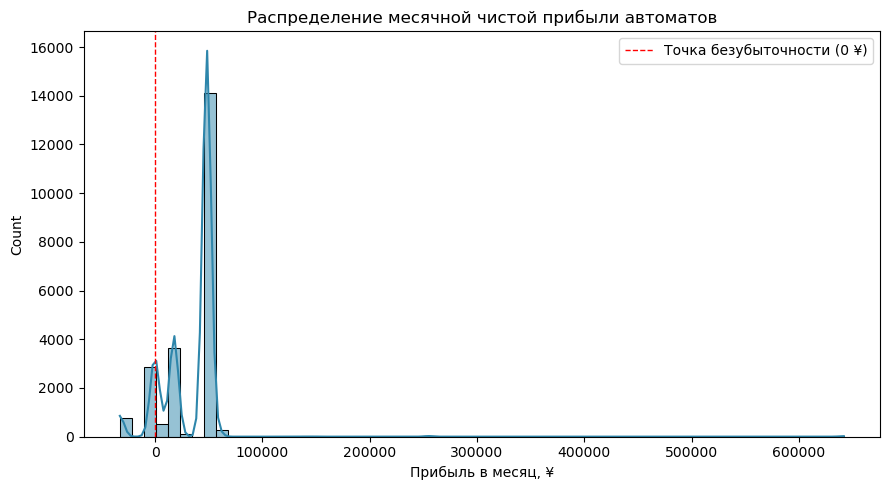

Автоматов с известной прибылью: 22261
Медиана: 48,076 ¥, среднее: 33,870 ¥


In [27]:
# Распределение monthly_net_profit_jpy
profit = df_clean['monthly_net_profit_jpy'].dropna()

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(profit, bins=60, kde=True, ax=ax, color='#2E86AB')
ax.axvline(0, color='red', linestyle='--', linewidth=1, label='Точка безубыточности (0 ¥)')
ax.set_xlabel('Прибыль в месяц, ¥')
ax.set_title('Распределение месячной чистой прибыли автоматов')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Автоматов с известной прибылью: {len(profit)}")
print(f"Медиана: {profit.median():,.0f} ¥, среднее: {profit.mean():,.0f} ¥")


Пики на распределении прибыли не стоит интерпретировать как реальные группы автоматов с одинаковой экономикой. Они возникают из-за того, что прибыль для автомата не рассчитывается отдельно на основе его реальных индивидуальных показателей, а берётся из заранее заданного типового значения для определённой категории. Всего для 22 категорий из 121: поэтому тысячи автоматов одной категории получают практически одинаковое значение прибыли.

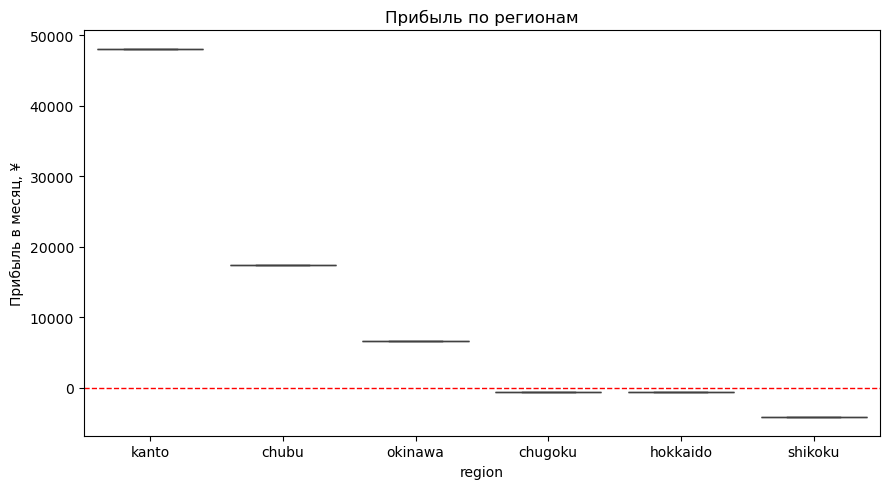

In [28]:
# Boxplot прибыли по регионам, отсортированным по медиане (без выбросов на самом графике - showfliers=False,
# чтобы редкие экстремальные значения не "сплющивали" основной график; сами выбросы уже разобраны в Блоке 2.2)
region_order = df_clean.groupby('region')['monthly_net_profit_jpy'].median().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df_clean, x='region', y='monthly_net_profit_jpy', order=region_order, color='#2E86AB', showfliers=False, ax=ax)
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_ylabel('Прибыль в месяц, ¥')
ax.set_title('Прибыль по регионам')
plt.tight_layout()
plt.show()


Chugoku, Hokkaido и Shikoku — убыточны. Если там уже стоят автоматы, стоит пересмотреть их размещение точка за точкой, а не расширяться там дальше. Kanto прибыльнее всех с большим отрывом — это регион приоритет №1 для новых инвестиций, если других данных (аренда, конкуренция) нет под рукой.

#### Блок 2.4 — Геоанализ

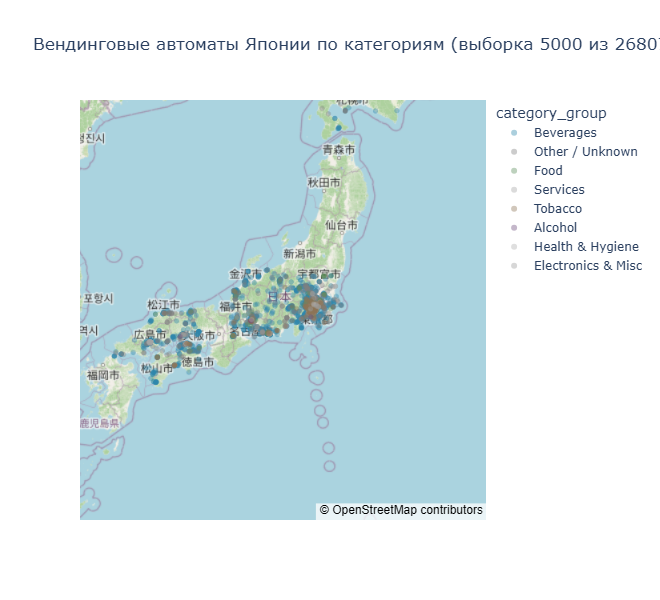

In [29]:
# Строим карту расположения вендинговых автоматов
sample_size = min(5000, len(df_clean))
map_sample = df_clean.dropna(subset=['lat', 'lon']).sample(sample_size, random_state=42)

fig = px.scatter_map(
    map_sample,
    lat='lat', lon='lon',
    color='category_group',
    color_discrete_map=category_colors,  # та же палитра, что и в Главе 3
    opacity=0.4,
    hover_data=['vending_category', 'operator_normalized', 'region', 'avg_markup_pct'],
    zoom=4,
    height=600,
    map_style='open-street-map',
    title=f'Вендинговые автоматы Японии по категориям (выборка {sample_size} из {len(df_clean)})'
)
fig.show()


Основная концентрация автоматов наблюдается на территории крупных и наиболее населённых городских агломераций, прежде всего в центральной части страны — в районах Токио, Нагои, Осаки и прилегающих городах.

По категориям наиболее заметны автоматы с напитками (Beverages) и продовольственными товарами (Food).

В северных и периферийных районах, особенно на Хоккайдо, а также в малонаселённых территориях, плотность автоматов значительно ниже. Таким образом, размещение вендинговых автоматов тесно связано с концентрацией населения, городской застройкой и экономической активностью.

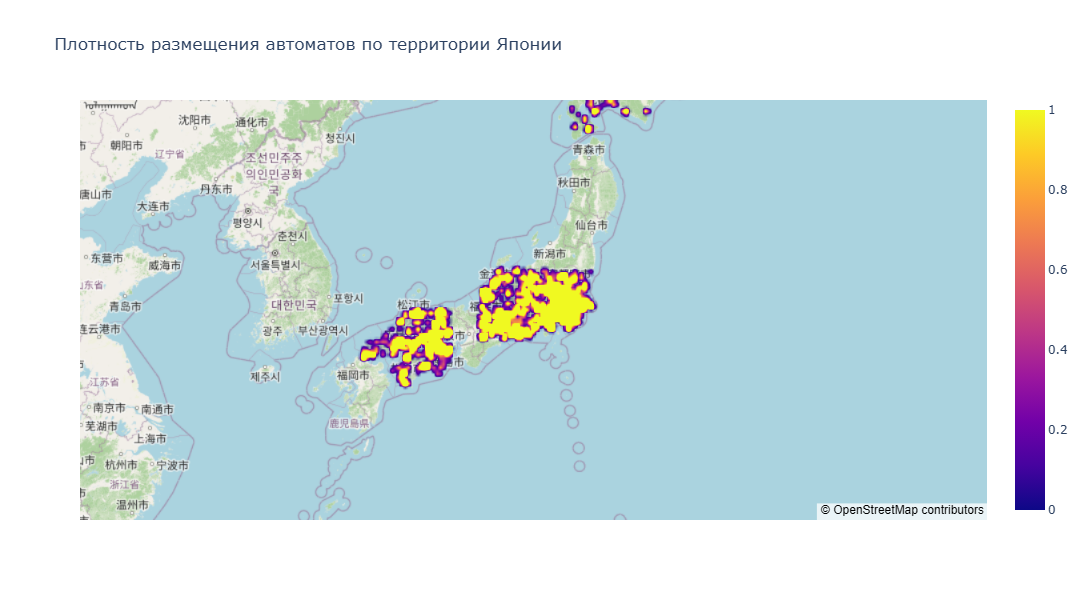

In [30]:
# Карта плотности - в отличие от точечной карты, здесь видно "тепловые" зоны без визуального шума от наложения точек
fig = px.density_map(
    df_clean.dropna(subset=['lat', 'lon']),
    lat='lat', lon='lon',
    radius=4,
    zoom=4,
    height=600,
    map_style='open-street-map',
    title='Плотность размещения автоматов по территории Японии'
)
fig.show()


Наибольшие значения плотности приходятся на крупнейшие префектуры Японии, тогда как периферийные и преимущественно сельские территории характеризуются значительно меньшей плотностью.

Особенно выделяется центральная часть острова Хонсю, где формируются крупные зоны высокой концентрации. Отдельные локальные очаги наблюдаются также на Хоккайдо и южных островах, однако они существенно уступают крупнейшим городским агломерациям.

#### Блок 2.5 — Итог главы

- **Приоритет инвестиций:** Регион Канто (Токио) является основной зоной для масштабирования сети. В регионах Тюгоку, Хоккайдо и Сикоку зафиксирована системная убыточность, рекомендуется точечный аудит действующих точек с последующим закрытием нерентабельных.
- **Управление маржинальностью:** Наценка — главный рычаг операционной прибыли. До принятия решения о смене локации необходимо провести сверку цен с региональными аналогами и скорректировать заниженные показатели.
- **Оптимизация операционных расходов:** Круглосуточный режим работы экономически оправдан только в регионе Тюбу (10,1%). Во всех остальных префектурах поддержание ночного графика генерирует убытки на фоне околонулевой выручки.
- **Специфика платежных решений:** Наличные остаются востребованным способом оплаты (2–20% транзакций). Интеграция IC-карт целесообразна только в агломерациях Токио и Саппоро; в южных префектурах Окинава и Сикоку этот функционал будет простаивать.
- **Ассортиментная матрица:** Основная доля рынка приходится на напитки и товары быстрого потребления. Высокая доля категории «Прочее» указывает на потенциал нишевых специализированных автоматов, требующих локального тестирования спроса перед полномасштабным внедрением.


### 3. Наценка и окупаемость

**Новый датасет для этой главы: агрегаты прибыли и окупаемости на уровне регион x группа категорий**

**`Датасет roi_estimates`:**
  - `region` — Регион Японии
  - `category_group` — Группа категорий товаров
  - `machines`— Количество автоматов в этой комбинации регион + категория
  - `avg_price_jpy`  — Средняя наценка оператора, %
  - `avg_monthly_revenue`  — Средняя выручка в месяц, ¥
  - `avg_monthly_profit`  — Среднемесячная прибыль, ¥
  - `avg_payback_months` — Средний срок окупаемости, месяцев
  - `pct_profitable` — Доля прибыльных вендинговых аппаратов %

In [31]:
roi_estimates = pd.read_csv('roi_estimates.csv')

print(f"Размер roi_estimates: {roi_estimates.shape[0]} строк, {roi_estimates.shape[1]} столбцов")
display(roi_estimates.head())


Размер roi_estimates: 28 строк, 9 столбцов


,region,category_group,machines,avg_price_jpy,avg_markup_pct,avg_monthly_revenue,avg_monthly_profit,avg_payback_months,pct_profitable
0,kanto,Electronics & Misc,18,1000.00,100.0,1350000.0,642000.0,0.5,1.0
1,chubu,Electronics & Misc,2,1000.00,100.0,840000.0,387000.0,0.8,1.0
2,kanto,Health & Hygiene,22,416.65,104.8,562478.0,254831.0,1.2,1.0
3,chugoku,Electronics & Misc,1,1000.00,100.0,540000.0,237000.0,1.3,1.0
4,hokkaido,Electronics & Misc,1,1000.00,100.0,540000.0,237000.0,1.3,1.0


#### Блок 3.1. — Какие товары наиболее выгодны для оператора?

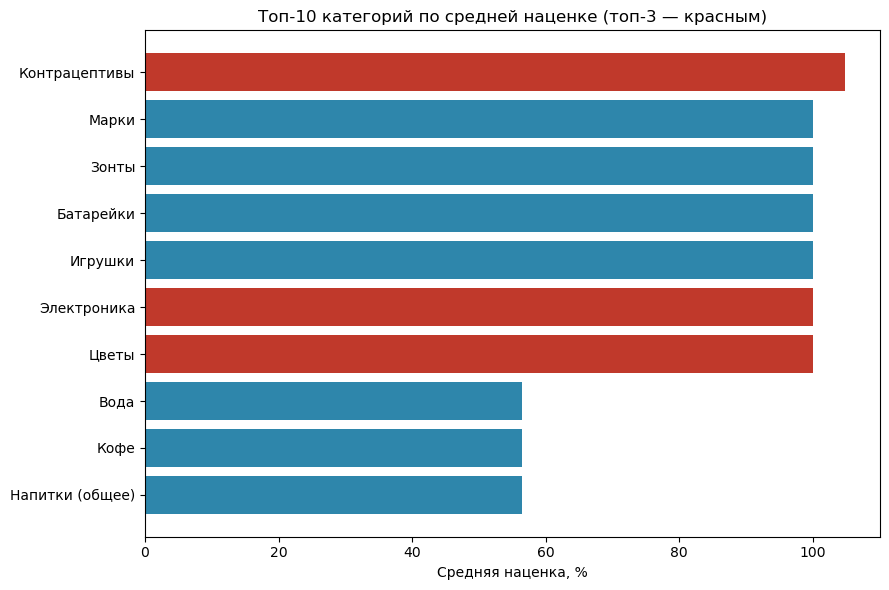

In [32]:
# Топ-10 категорий по средней наценке (avg_markup_pct), топ-3 выделяем отдельным цветом
category_by_markup = category.dropna(subset=['avg_markup_pct']).sort_values('avg_markup_pct', ascending=False)
top10_markup = category_by_markup.head(10).sort_values('avg_markup_pct')  # ascending - для barh, чтобы лидер был сверху

top3_names = set(category_by_markup.head(3)['vending_category'])
bar_colors = ['#C0392B' if name in top3_names else '#2E86AB' for name in top10_markup['vending_category']]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top10_markup['vending_category'].astype(str), top10_markup['avg_markup_pct'], color=bar_colors)
ax.set_xlabel('Средняя наценка, %')
ax.set_title('Топ-10 категорий по средней наценке (топ-3 — красным)')
plt.tight_layout()
plt.show()


Наибольшая средняя наценка наблюдается в категориях **«Контрацептивы» — около 105%, а также «Электроника» и «Цветы» — около 100%**. Эти категории выглядят наиболее маржинальными и заслуживают внимания при расширении ассортимента.

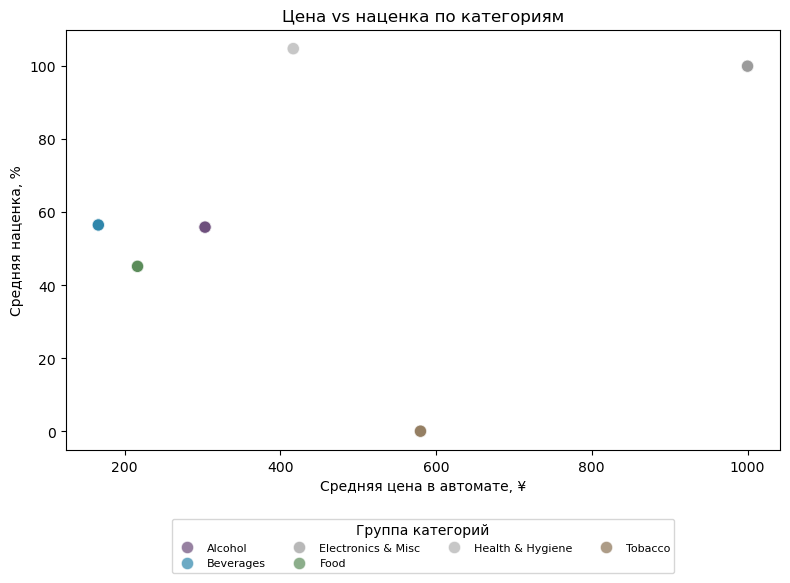

In [33]:
# Цена vs наценка
scatter_data = category.dropna(subset=['avg_vending_price', 'avg_markup_pct'])

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=scatter_data,
    x='avg_vending_price', y='avg_markup_pct',
    hue='category_group', palette=category_colors,
    alpha=0.7, s=80, ax=ax
)
ax.set_xlabel('Средняя цена в автомате, ¥')
ax.set_ylabel('Средняя наценка, %')
ax.set_title('Цена vs наценка по категориям')
ax.legend(title='Группа категорий', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, fontsize=8)
plt.tight_layout()
plt.show()


Зависимость между средней ценой товара и наценкой выражена слабо. Например, **Health & Hygiene и Electronics & Misc** имеют высокую наценку, но находятся в разных ценовых сегментах. Это означает, что ценовую и ассортиментную стратегию лучше формировать индивидуально для каждой категории, а не ориентироваться только на среднюю цену товара.

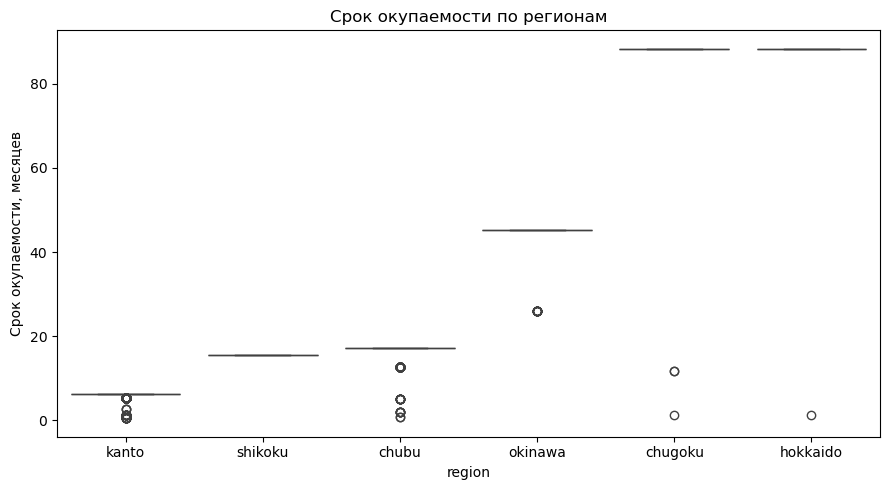

In [34]:
# Как распределён срок окупаемости по регионам без искажающих выбросов?
clean_payback = df_clean[~df_clean['payback_months_outlier']]
region_order_payback = clean_payback.groupby('region')['payback_months'].median().sort_values().index

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=clean_payback, x='region', y='payback_months', order=region_order_payback, color='#2E86AB', ax=ax)
ax.set_ylabel('Срок окупаемости, месяцев')
ax.set_title('Срок окупаемости по регионам')
plt.tight_layout()
plt.show()


График показывает очень сильный разброс эффективности внутри регионов. В Канто большинство точек окупается быстро — в течение нескольких месяцев, хотя встречаются отдельные выбросы. В Чубу также есть быстро окупаемые точки, но разброс значительно выше. В Окинаве, Тюгоку и Хоккайдо типичный срок окупаемости существенно выше, что говорит о более высоком инвестиционном риске.

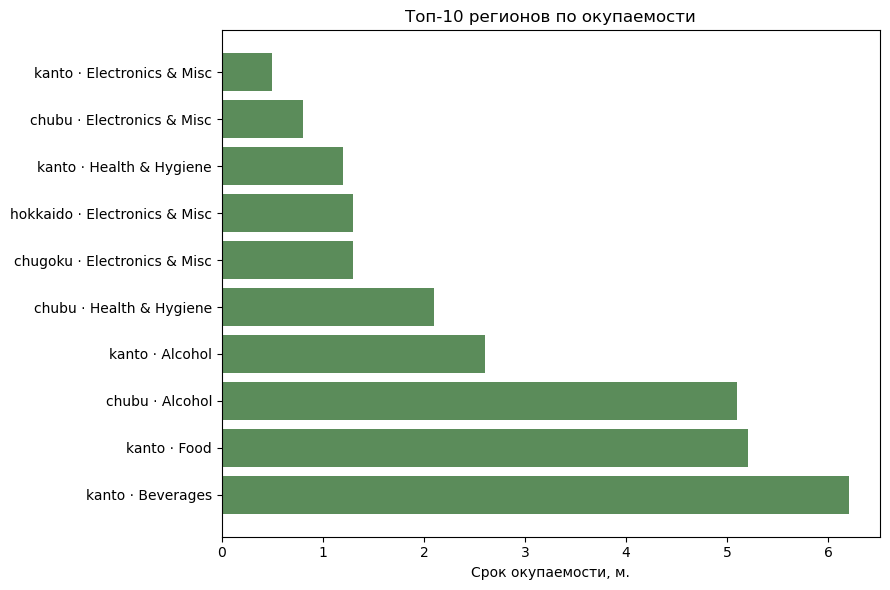

In [35]:
# Топ-10 комбинаций регион + категория по минимальному сроку окупаемости
fastest_combos = roi_estimates.dropna(subset=['avg_payback_months']).sort_values('avg_payback_months').head(10).copy()
fastest_combos['label'] = fastest_combos['region'] + ' · ' + fastest_combos['category_group']
fastest_combos = fastest_combos.sort_values('avg_payback_months', ascending=False)  # для barh - лидер сверху

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(fastest_combos['label'], fastest_combos['avg_payback_months'], color='#5B8C5A')
ax.set_xlabel('Срок окупаемости, м.')
ax.set_title('Топ-10 регионов по окупаемости')
plt.tight_layout()
plt.show()


Наиболее быстро окупаются **Electronics & Misc в Канто и Чубу, а также Health & Hygiene в Канто**. Самые длительные сроки окупаемости наблюдаются у отдельных комбинаций в Чубу, Окинаве и других регионах. Приоритет при масштабировании стоит отдавать комбинациям с коротким сроком возврата инвестиций.

#### Блок 3.2. — Какой регион наиболее привлекателен для инвестиций?

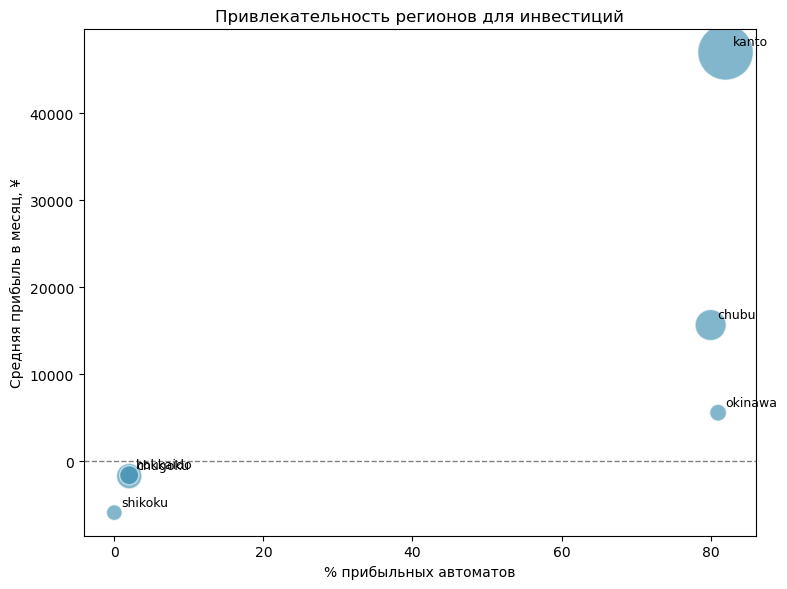

In [36]:
# Scatter: % прибыльных автоматов (X) vs средняя прибыль (Y), размер точки = число автоматов в регионе.
point_sizes = region['total_machines'] / region['total_machines'].max() * 1500 + 100

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(region['pct_profitable'] * 100, region['avg_monthly_profit'], s=point_sizes, color='#2E86AB', alpha=0.6, edgecolors='white')

for _, row in region.iterrows():
    ax.annotate(row['region'], (row['pct_profitable'] * 100, row['avg_monthly_profit']), xytext=(5, 5), textcoords='offset points', fontsize=9)

ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('% прибыльных автоматов')
ax.set_ylabel('Средняя прибыль в месяц, ¥')
ax.set_title('Привлекательность регионов для инвестиций')
plt.tight_layout()
plt.show()


Канто — главный приоритет для инвестиций: высокая доля прибыльных автоматов, большая сеть и максимальная прибыль. Чубу также выглядит привлекательным для расширения. Окинава имеет высокий процент прибыльных автоматов, но меньший масштаб. Хоккайдо, Тюгоку и Сикоку требуют осторожности из-за низкой прибыльности и более длительной окупаемости

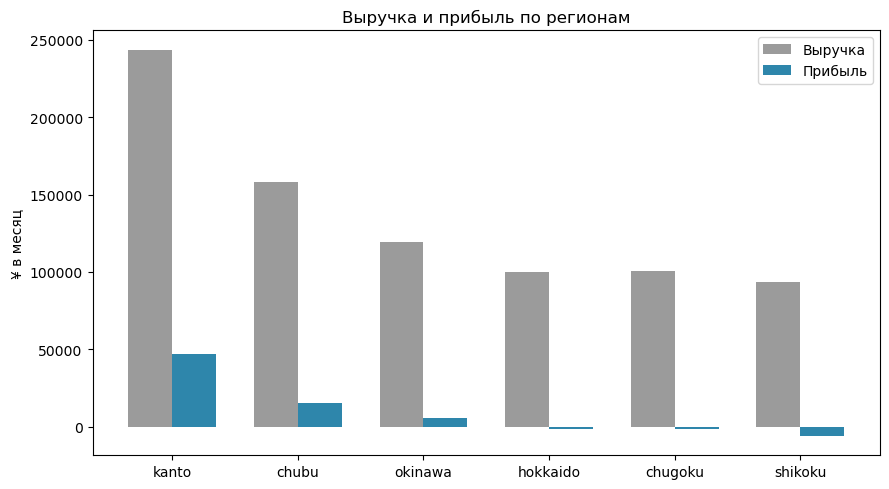

In [37]:
# Grouped bar: выручка и прибыль рядом по каждому региону - разрыв между ними = операционные расходы
region_by_profit = region.sort_values('avg_monthly_profit', ascending=False)
x = np.arange(len(region_by_profit))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, region_by_profit['avg_monthly_revenue'], width, label='Выручка', color='#9B9B9B')
ax.bar(x + width/2, region_by_profit['avg_monthly_profit'], width, label='Прибыль', color='#2E86AB')
ax.set_xticks(x)
ax.set_xticklabels(region_by_profit['region'])
ax.set_ylabel('¥ в месяц')
ax.set_title('Выручка и прибыль по регионам')
ax.legend()
plt.tight_layout()
plt.show()


Канто значительно опережает остальные регионы по выручке и прибыли. Чубу занимает второе место и также показывает положительную экономику. Окинава приносит прибыль, но пока имеет небольшой масштаб. Хоккайдо, Тюгоку и Сикоку работают с отрицательной средней прибылью, поэтому расширять присутствие там без оптимизации нецелесообразно.

**Итоговая сравнительная таблица по регионам**

In [38]:
# Итоговая таблица с условным форматированием: зелёный - лучшее значение в колонке, красный - худшее.
summary_columns = ['total_machines', 'avg_markup_pct', 'avg_monthly_revenue', 'avg_monthly_profit', 'pct_profitable']
region_summary = region.set_index('region')[summary_columns].sort_values('avg_monthly_profit', ascending=False)

region_summary_styled = (
    region_summary.style
    .background_gradient(cmap='RdYlGn', subset=summary_columns)
    .format({
        'total_machines': '{:,.0f}',
        'avg_markup_pct': '{:.1f}%',
        'avg_monthly_revenue': '¥{:,.0f}',
        'avg_monthly_profit': '¥{:,.0f}',
        'pct_profitable': '{:.0%}',
    })
)

region_summary_styled


,total_machines,avg_markup_pct,avg_monthly_revenue,avg_monthly_profit,pct_profitable
region,,,,,
kanto,"17,488",54.8%,"¥243,429","¥46,993",82%
chubu,"4,676",53.6%,"¥158,253","¥15,662",80%
okinawa,538,54.3%,"¥119,496","¥5,592",81%
hokkaido,"1,064",54.0%,"¥100,293","¥-1,590",2%
chugoku,"2,724",53.8%,"¥100,409","¥-1,697",2%
shikoku,317,52.5%,"¥93,788","¥-5,888",0%


Итоговые показатели подтверждают лидерство **Канто: 17,5 тыс**. автоматов, около 55% средней наценки, максимальная выручка и ≈82% прибыльных автоматов. Чубу также показывает сильный результат — около 80% прибыльных автоматов. Окинава выделяется высокой долей прибыльных точек (≈81%), но небольшим масштабом. Хоккайдо и Тюгоку имеют около 2% прибыльных автоматов, а Сикоку — 0%, что делает их наиболее проблемными направлениями.

#### Блок 3.3. — Итог Главы

Основной потенциал сейчас находится в Канто и Чубу, где высокая прибыльность сочетается с относительно быстрой окупаемостью. Окинаву можно развивать более точечно.

При выборе новых мест установки стоит ориентироваться на конкретную локацию, категорию товара, ожидаемую выручку и срок окупаемости. Высокомаржинальные категории могут увеличить доходность автомата, но ключевым фактором остаётся покупательский поток.

А в проблемных регионах — Хоккайдо, Тюгоку и Сикоку — сначала нужно найти причины низкой эффективности автоматов: неудачные локации, недостаточный спрос, ассортимент или слишком высокие операционные расходы. Только после этого имеет смысл принимать решение о дальнейшем расширении.

### 4. Конкурентный анализ операторов


In [39]:
# Исключаем 'Unknown' из конкурентного анализа
operator_known = operator[operator['operator_normalized'] != 'Unknown'].copy()
df_known_operator = df_clean[df_clean['operator_normalized'] != 'Unknown'].copy()

print(f"Операторов в справочнике всего (с Unknown): {len(operator)}")
print(f"Из них с известным названием (без Unknown):  {len(operator_known)}")
print(f"Автоматов у операторов с известным названием: {len(df_known_operator)} из {len(df_clean)}")


Операторов в справочнике всего (с Unknown): 439
Из них с известным названием (без Unknown):  438
Автоматов у операторов с известным названием: 7285 из 26807


#### Блок 4.1. — Операторы

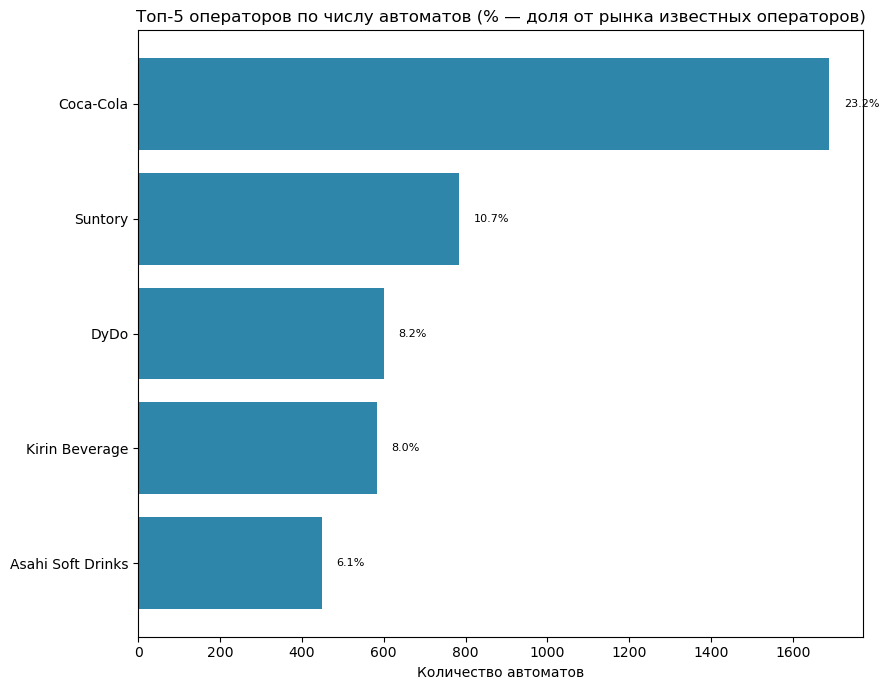

In [40]:
# Топ-15 операторов по machines_count, подписываем % от рынка известных операторов
top15_operators = operator_known.sort_values('machines_count', ascending=False).head(5)
total_known_machines = operator_known['machines_count'].sum()
top15_operators_sorted = top15_operators.sort_values('machines_count')  # ascending - для barh, лидер сверху

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(top15_operators_sorted['operator_normalized'], top15_operators_sorted['machines_count'], color='#2E86AB')

for bar, count in zip(bars, top15_operators_sorted['machines_count']):
    share_pct = count / total_known_machines * 100
    ax.text(bar.get_width() + total_known_machines * 0.005, bar.get_y() + bar.get_height() / 2, f'{share_pct:.1f}%', va='center', fontsize=8)

ax.set_xlabel('Количество автоматов')
ax.set_title('Топ-5 операторов по числу автоматов (% — доля от рынка известных операторов)')
plt.tight_layout()
plt.show()


Coca-Cola — явный лидер рынка: около 23,2% автоматов среди известных операторов, что более чем в 2 раза больше доли Suntory (10,7%). Далее идут DyDo (8,2%), Kirin Beverage (8,0%) и Asahi Soft Drinks (6,1%).

#### Блок 4.2. — Географический охват операторов

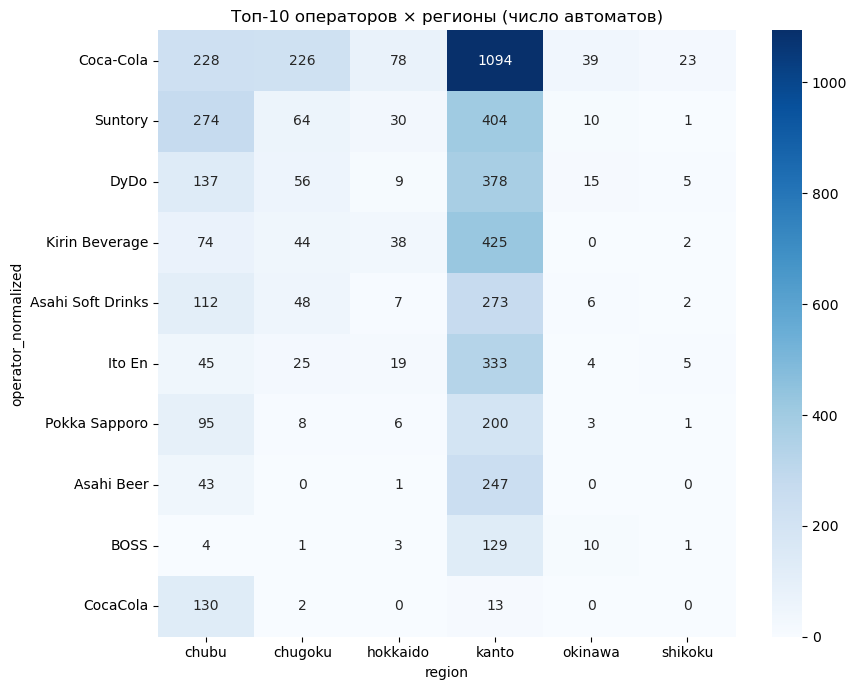

In [41]:
# Сколько автоматов у каждого из топ-10 операторов в каждом регионе
top10_names = operator_known.sort_values('machines_count', ascending=False).head(10)['operator_normalized']

operator_region_counts = pd.crosstab(df_known_operator['operator_normalized'], df_known_operator['region'])
operator_region_counts = operator_region_counts.loc[top10_names]  # оставляем и сортируем только топ-10

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(operator_region_counts, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Топ-10 операторов × регионы (число автоматов)')
plt.tight_layout()
plt.show()


Наиболее высокая концентрация операторов наблюдается в Канто. Здесь у Coca-Cola — 1 094 автомата, у Kirin Beverage — 425, у Suntory — 404, у DyDo — 378. В остальных регионах количество автоматов значительно ниже.

#### Блок 4.3. — Специализация и инвестиции в удобство

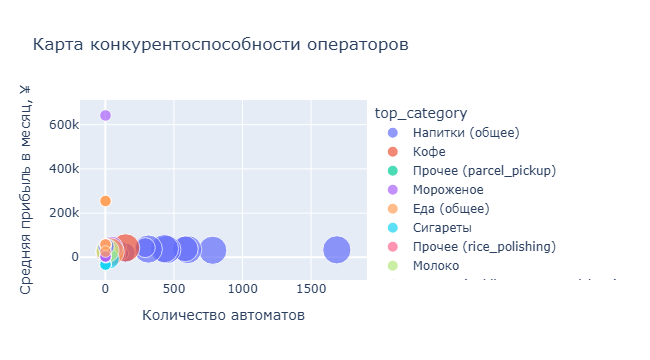

In [42]:
# Интерактивный scatter: X - масштаб (сколько автоматов), Y - прибыльность,
# размер точки - географический охват (regions_count), цвет - на чём специализируется оператор
fig = px.scatter(
    operator_known,
    x='machines_count', y='avg_monthly_profit',
    size='regions_count', color='top_category',
    hover_data=['operator_normalized'],
    title='Карта конкурентоспособности операторов',
    labels={'machines_count': 'Количество автоматов', 'avg_monthly_profit': 'Средняя прибыль в месяц, ¥'}
)
fig.show()


График показывает, что большое количество автоматов не всегда означает максимальную прибыль на автомат. Крупнейшие операторы получают преимущество за счёт масштаба сети, тогда как отдельные операторы с меньшим количеством автоматов демонстрируют высокую среднюю прибыль.

#### Блок 4.2. — Итог главы

Рынок вендинга характеризуется сильной конкуренцией крупных операторов, при этом Coca-Cola занимает наиболее заметную позицию. Основное конкурентное преимущество лидеров — масштаб и широкое присутствие, особенно в Канто.

Однако графики показывают, что масштаб сети не является единственным фактором успеха. Небольшие операторы могут конкурировать за счёт высокой прибыльности отдельных автоматов, правильного выбора категорий и локаций.

Для развития вендингового бизнеса оптимальная стратегия — не пытаться сразу конкурировать с лидерами, а сосредоточиться на качественных локациях, высокомаржинальных категориях и коротким сроком окупаемости.


### 5. Итоги

1. **Топ-категория товаров.** Основу выборки составляют автоматы категории **Beverages (напитки)** — 20 660 записей, что значительно больше остальных категорий, поэтому именно напитки являются основной категорией рынка в исследуемых данных.

2. **География.** Наибольшая концентрация автоматов наблюдается в **Канто** — около 17,5 тыс. установок, что значительно превышает остальные регионы. Канто также характеризуется высокой долей напитков (81%) и наиболее высокой средней месячной прибылью — около **46,9 тыс. ¥ на автомат**. При этом Чубу занимает второе место по масштабу и демонстрирует положительную экономику, тогда как Хоккайдо и Тюгоку имеют отрицательную среднюю прибыль.

3. **Наценка по категориям.** Наиболее высокая средняя наценка наблюдается у категорий **«Контрацептивы» — около 105%, «Электроника» и «Цветы» — около 100%**. Эти категории потенциально привлекательны с точки зрения маржинальности, однако высокая наценка сама по себе не гарантирует высокой итоговой прибыли: необходимо учитывать объём спроса и количество продаж.

4. **Скорость окупаемости.** Анализ сроков окупаемости показывает существенный разброс эффективности внутри регионов. Наиболее привлекательными выглядят комбинации **Electronics & Misc в Канто и Чубу, а также Health & Hygiene в Канто**, поскольку они характеризуются коротким расчётным сроком возврата инвестиций. При этом в отдельных комбинациях регионов наблюдаются значительно более длительные сроки окупаемости, что увеличивает инвестиционный риск.

5. **Регион-лидер по прибыли.** **Канто является наиболее привлекательным регионом для новых установок**: здесь одновременно наблюдаются крупнейший масштаб сети, максимальная средняя месячная прибыль и около 82% прибыльных автоматов. Чубу можно рассматривать как второе направление для расширения, а Окинаву — как более нишевый рынок. Хоккайдо, Тюгоку и Сикоку требуют предварительной оптимизации существующих точек, прежде чем рассматривать дальнейшее масштабирование.

6. **Концентрация рынка.** Конкурентный анализ показывает заметное присутствие крупных операторов: среди автоматов с известным оператором **Coca-Cola занимает около 23,2%**, далее следуют Suntory — 10,7%, DyDo — 8,2%, Kirin Beverage — 8,0% и Asahi Soft Drinks — 6,1%. При этом 72,82% автоматов не имеют указанного оператора, поэтому показатель концентрации необходимо интерпретировать с осторожностью.

### Бизнес-рекомендации

**Для оператора.** Основной приоритет при расширении сети следует отдавать **Канто**, а вторым направлением рассматривать **Чубу**. При выборе конкретных точек необходимо оценивать не только регион, но и категорию товара, ожидаемую выручку и срок окупаемости. В проблемных регионах сначала целесообразно провести оптимизацию существующих автоматов и определить причины низкой эффективности.

**Для инвестора.** Наиболее интересными могут быть категории с высокой наценкой и одновременно ограниченным присутствием в текущей выборке, например электроника, цветы и Health & Hygiene. Однако перед масштабированием необходимо подтвердить наличие достаточного спроса, поскольку высокая маржа без достаточного объёма продаж не гарантирует высокой прибыли.

**Для конкурентной стратегии.** Крупные операторы обладают преимуществом масштаба, особенно в Канто, однако масштаб сети не является единственным фактором прибыльности. Небольшие операторы могут конкурировать за счёт выбора перспективных категорий и более эффективных локаций.

### Ограничения исследования

Полученные результаты необходимо интерпретировать с учётом ограничений данных. Финансовые показатели в `master_dataset` являются **оценочными**, а не фактическими данными о продажах конкретных автоматов. Около 16,96% записей не имеют финансовых показателей, поскольку для части категорий отсутствуют справочные цены.

Кроме того, данные OpenStreetMap могут не отражать все существующие автоматы Японии, а полнота покрытия может различаться между регионами. Значительная часть автоматов также не имеет информации об операторе: конкурентный анализ основан только на 7 285 автоматах с известным оператором из 26 807.

Таким образом, результаты следует рассматривать прежде всего как **аналитическую основу для выбора перспективных регионов, категорий и типов локаций**, а не как точную финансовую оценку будущих инвестиций.




### Итоговый датасет для BI

**Ищем пересечения названий колонок**

In [43]:
# Смотрим, какие названия колонок пересекаются с df_clean - это и есть будущие дубли, если не переименовать
print("Пересечение с category:", set(category.columns) & set(df_clean.columns))
print("Пересечение с operator:", set(operator.columns) & set(df_clean.columns))
print("Пересечение с region:  ", set(region.columns) & set(df_clean.columns))


Пересечение с category: {'category_group', 'avg_markup_pct', 'vending_category'}
Пересечение с operator: {'operator_normalized', 'avg_markup_pct'}
Пересечение с region:   {'avg_markup_pct', 'region'}


**Переименовываем колонки справочников перед объединением**

In [44]:
# Готовим копии справочников с переименованными колонками, чтобы после merge не было дублей
category_for_merge = category.drop(columns=['category_group']).rename(columns={
    'count': 'category_machines_count',
    'avg_vending_price': 'category_avg_vending_price',
    'avg_markup_pct': 'category_avg_markup_pct',
    'avg_monthly_profit': 'category_avg_monthly_profit',
    'avg_payback_months': 'category_avg_payback_months',
})

operator_for_merge = operator.rename(columns={
    'machines_count': 'operator_machines_count',
    'regions_count': 'operator_regions_count',
    'pct_24h': 'operator_pct_24h',
    'pct_ic_card': 'operator_pct_ic_card',
    'avg_markup_pct': 'operator_avg_markup_pct',
    'avg_monthly_profit': 'operator_avg_monthly_profit',
    'top_category': 'operator_top_category',
})

region_for_merge = region.rename(columns={
    'total_machines': 'region_total_machines',
    'pct_24h': 'region_pct_24h',
    'pct_beverages': 'region_pct_beverages',
    'pct_food': 'region_pct_food',
    'pct_tobacco': 'region_pct_tobacco',
    'avg_markup_pct': 'region_avg_markup_pct',
    'avg_monthly_revenue': 'region_avg_monthly_revenue',
    'avg_monthly_profit': 'region_avg_monthly_profit',
    'pct_profitable': 'region_pct_profitable',
})


**Проверяем, что ключ объединения уникален в каждом справочнике**

In [45]:
print("vending_category уникален в category:      ", category_for_merge['vending_category'].is_unique)
print("operator_normalized уникален в operator:    ", operator_for_merge['operator_normalized'].is_unique)
print("region уникален в region:                   ", region_for_merge['region'].is_unique)


vending_category уникален в category:       True
operator_normalized уникален в operator:     True
region уникален в region:                    True


**Объединяем таблицы**

In [46]:
rows_before = len(df_clean)

df_full = df_clean.merge(category_for_merge, on='vending_category', how='left')
df_full = df_full.merge(operator_for_merge, on='operator_normalized', how='left')
df_full = df_full.merge(region_for_merge, on='region', how='left')

print(f"Строк до объединения:    {rows_before}")
print(f"Строк после объединения: {len(df_full)}")

assert len(df_full) == rows_before, "После merge изменилось число строк - где-то ключ не уникален!"


Строк до объединения:    26807
Строк после объединения: 26807


**Финальная проверка на дубли колонок**

In [47]:
# Убеждаемся, что дублирующихся названий колонок не осталось
duplicate_columns = df_full.columns[df_full.columns.duplicated()].tolist()
print(f"Дублирующихся названий колонок: {len(duplicate_columns)}")
print(duplicate_columns)

print(f"\nРазмер df_full: {df_full.shape[0]} строк, {df_full.shape[1]} столбцов")
display(df_full.head())


Дублирующихся названий колонок: 0
[]

Размер df_full: 26807 строк, 47 столбцов


,osm_id,osm_type,lat,lon,region,vending_raw,vending_primary,vending_category,category_group,operator_normalized,...,operator_top_category,region_total_machines,region_pct_24h,region_pct_beverages,region_pct_food,region_pct_tobacco,region_avg_markup_pct,region_avg_monthly_revenue,region_avg_monthly_profit,region_pct_profitable
0,1555169728,node,43.763039,142.357919,hokkaido,public_transport_tickets,public_transport_tickets,Прочее (public_transport_tickets),Other / Unknown,北海道旅客鉄道,...,Прочее (public_transport_tickets),1064,0.0,0.77,0.02,0.03,53.95,100292.78,-1590.39,0.02
1,1555752459,node,43.762670,142.359134,hokkaido,public_transport_tickets,public_transport_tickets,Прочее (public_transport_tickets),Other / Unknown,北海道旅客鉄道,...,Прочее (public_transport_tickets),1064,0.0,0.77,0.02,0.03,53.95,100292.78,-1590.39,0.02
2,1775913293,node,43.730989,142.365826,hokkaido,public_transport_tickets,public_transport_tickets,Прочее (public_transport_tickets),Other / Unknown,北海道旅客鉄道,...,Прочее (public_transport_tickets),1064,0.0,0.77,0.02,0.03,53.95,100292.78,-1590.39,0.02
3,2144929234,node,43.744976,142.358386,hokkaido,public_transport_tickets,public_transport_tickets,Прочее (public_transport_tickets),Other / Unknown,JR北海道,...,Прочее (public_transport_tickets),1064,0.0,0.77,0.02,0.03,53.95,100292.78,-1590.39,0.02
4,2152896706,node,43.765918,142.359128,hokkaido,public_transport_tickets,public_transport_tickets,Прочее (public_transport_tickets),Other / Unknown,旭川電気軌道,...,Прочее (public_transport_tickets),1064,0.0,0.77,0.02,0.03,53.95,100292.78,-1590.39,0.02


**Приводим типы к BI-совместимым**

In [48]:
df_bi = df_full.copy()

# Булевы колонки переводим в 0/1
bool_columns = df_bi.select_dtypes(include='bool').columns.tolist()
print(f"Булевы колонки, которые переводим в 0/1: {bool_columns}")

for col in bool_columns:
    df_bi[col] = df_bi[col].astype(int)


Булевы колонки, которые переводим в 0/1: ['payback_months_outlier']


**Сохраняем итоговый датасет и словарь данных**

In [49]:
# Сохраняем финальный датасет одним CSV-файлом
df_bi.to_csv('vending_dataset_for_bi.csv', index=False, encoding='utf-8-sig')

print(f"Итоговый размер df_bi: {df_bi.shape[0]} строк, {df_bi.shape[1]} столбцов")
print("Сохранено в vending_dataset_for_bi.csv")

data_dictionary = pd.DataFrame({
    'column': df_bi.columns,
    'dtype': df_bi.dtypes.astype(str).values,
    'missing_pct': (df_bi.isna().sum() / len(df_bi) * 100).round(2).values,
})
data_dictionary.to_csv('vending_dataset_for_bi_data_dictionary.csv', index=False, encoding='utf-8-sig')

display(data_dictionary)


Итоговый размер df_bi: 26807 строк, 47 столбцов
Сохранено в vending_dataset_for_bi.csv


,column,dtype,missing_pct
0,osm_id,int64,0.00
1,osm_type,object,0.00
2,lat,float64,0.00
3,lon,float64,0.00
4,region,object,0.00
5,vending_raw,object,10.39
6,vending_primary,object,0.00
7,vending_category,object,0.00
8,category_group,object,0.00
9,operator_normalized,object,0.00
